# Predicting the Beats-per-Minute of Songs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge,Lasso
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.tree import ExtraTreeRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error


import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s5e9/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s5e9/test.csv")

In [3]:
print(train.shape)
print(test.shape)

(524164, 11)
(174722, 10)


In [4]:
train.head()

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511


In [5]:
train.isnull().sum()

id                           0
RhythmScore                  0
AudioLoudness                0
VocalContent                 0
AcousticQuality              0
InstrumentalScore            0
LivePerformanceLikelihood    0
MoodScore                    0
TrackDurationMs              0
Energy                       0
BeatsPerMinute               0
dtype: int64

## EDA

In [6]:
df=pd.concat([train,test])

In [7]:
df.head()

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 698886 entries, 0 to 174721
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         698886 non-null  int64  
 1   RhythmScore                698886 non-null  float64
 2   AudioLoudness              698886 non-null  float64
 3   VocalContent               698886 non-null  float64
 4   AcousticQuality            698886 non-null  float64
 5   InstrumentalScore          698886 non-null  float64
 6   LivePerformanceLikelihood  698886 non-null  float64
 7   MoodScore                  698886 non-null  float64
 8   TrackDurationMs            698886 non-null  float64
 9   Energy                     698886 non-null  float64
 10  BeatsPerMinute             524164 non-null  float64
dtypes: float64(10), int64(1)
memory usage: 64.0 MB


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,698886.0,349442.500000,201751.154454,0.000000,174721.250000,349442.500000,524163.750000,698885.000000
RhythmScore,698886.0,0.632780,0.156982,0.076900,0.515768,0.634682,0.739179,0.975000
AudioLoudness,698886.0,-8.378635,4.617735,-27.509725,-11.551713,-8.252704,-4.909687,-1.357000
VocalContent,698886.0,0.074451,0.049960,0.023500,0.023500,0.066426,0.107329,0.258857
AcousticQuality,698886.0,0.262910,0.223065,0.000005,0.069421,0.242467,0.396941,0.995000
InstrumentalScore,698886.0,0.117619,0.131791,0.000001,0.000001,0.074202,0.203934,0.869258
LivePerformanceLikelihood,698886.0,0.178378,0.118180,0.024300,0.077640,0.166040,0.268884,0.599924
MoodScore,698886.0,0.555848,0.225665,0.025600,0.403898,0.564960,0.716644,0.978000
TrackDurationMs,698886.0,241866.203709,59270.996893,63973.000000,207099.986725,243629.488550,281809.660600,464723.228100
Energy,698886.0,0.500828,0.290102,0.000067,0.254800,0.511867,0.746067,1.000000


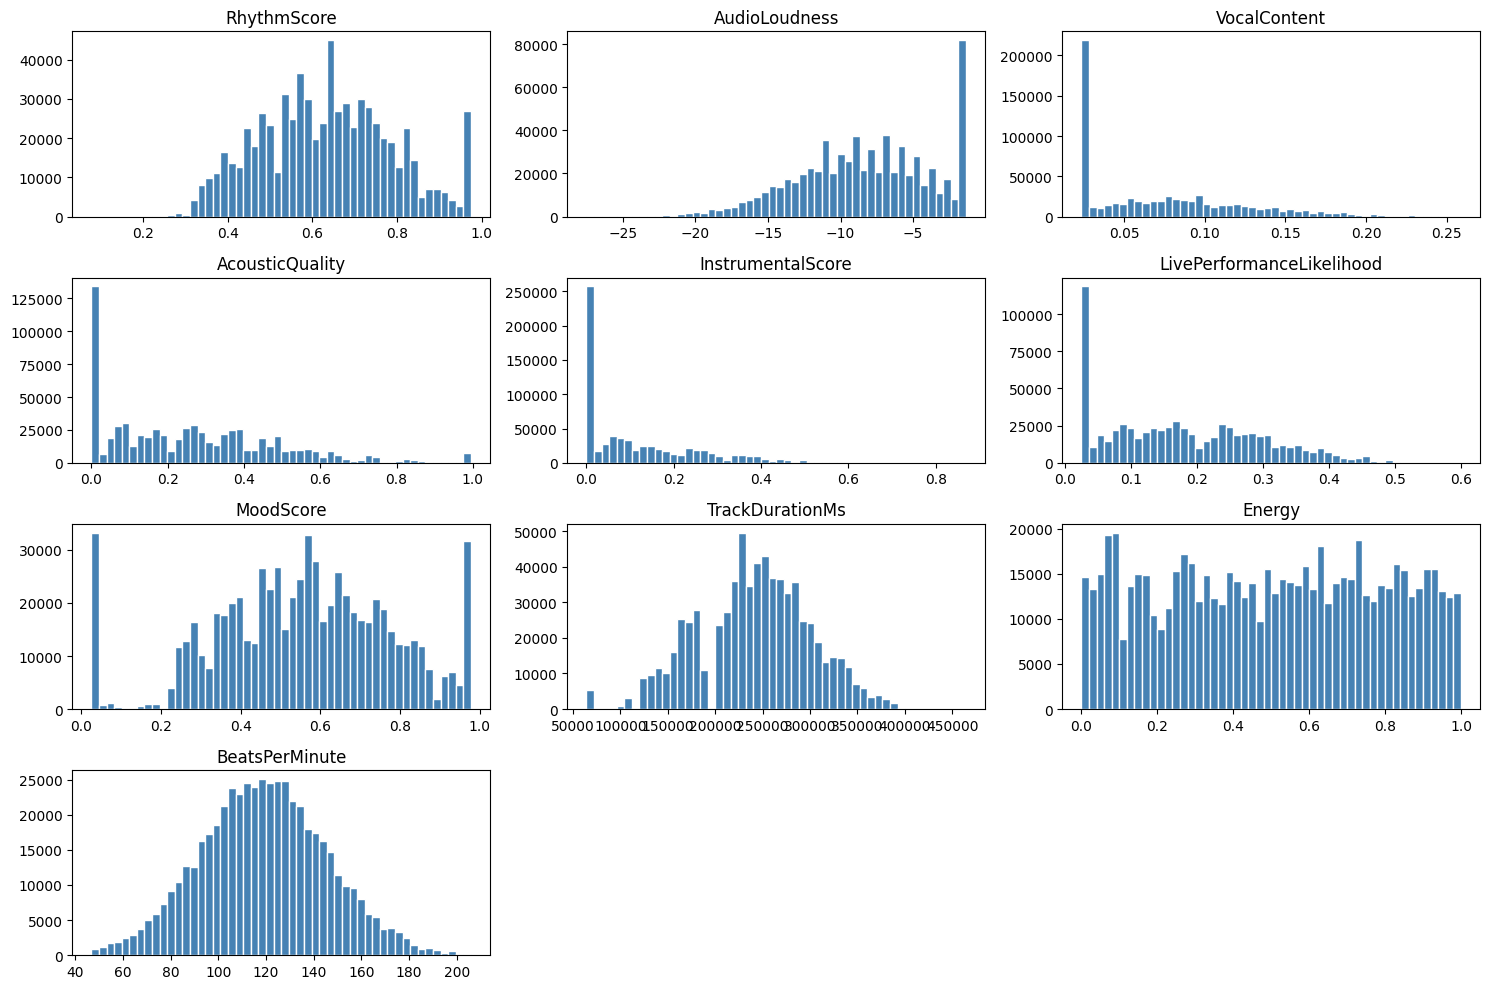

In [10]:
#Numeric cols
num_cols = ['RhythmScore', 'AudioLoudness', 'VocalContent', 'AcousticQuality',
            'InstrumentalScore', 'LivePerformanceLikelihood', 'MoodScore',
            'TrackDurationMs', 'Energy', 'BeatsPerMinute']

plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 3, i)
    plt.hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='white')
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

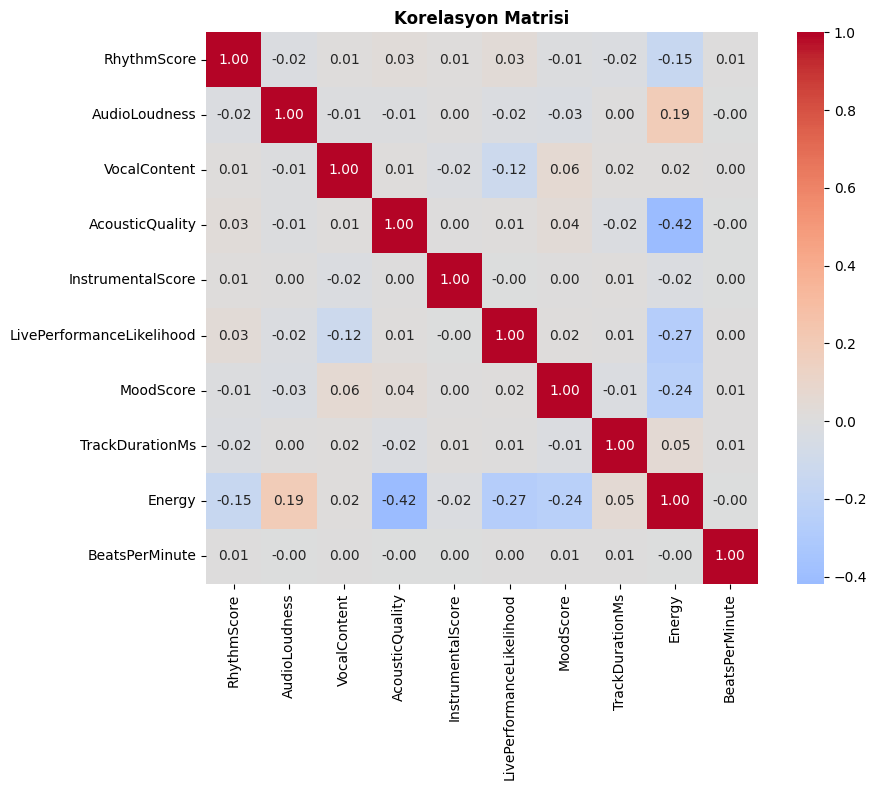

In [11]:
# Corelation Heatmap
numeric_with_target = num_cols
correlation_matrix = train[numeric_with_target].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Korelasyon Matrisi', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Feature Engineering

In [12]:
abs(df.corr(numeric_only=True))['BeatsPerMinute'].sort_values(ascending=False)

BeatsPerMinute               1.000000
MoodScore                    0.007059
TrackDurationMs              0.006637
RhythmScore                  0.005440
VocalContent                 0.004876
Energy                       0.004375
LivePerformanceLikelihood    0.003471
AudioLoudness                0.003327
InstrumentalScore            0.001900
AcousticQuality              0.000820
id                           0.000355
Name: BeatsPerMinute, dtype: float64

In [13]:
df['energy_rhythm']     = df['Energy'] * df['RhythmScore']
df['energy_loudness']   = df['Energy'] * df['AudioLoudness'].abs()

In [14]:
df['acoustic_instrumental'] = df['AcousticQuality'] * df['InstrumentalScore']
df['acoustic_energy_ratio'] = df['AcousticQuality'] / (df['Energy'] + 1e-5)

In [15]:
df['loudness_mood']  = df['AudioLoudness'].abs() * df['MoodScore']
df['mood_energy'] = df['MoodScore'] * df['Energy']

In [16]:
df['vocal_live'] = df['VocalContent'] * df['LivePerformanceLikelihood']

In [17]:
df['TrackDurationSec'] = df['TrackDurationMs'] / 1000

In [18]:
abs(df.corr(numeric_only=True))['BeatsPerMinute'].sort_values(ascending=False)

BeatsPerMinute               1.000000
MoodScore                    0.007059
TrackDurationMs              0.006637
TrackDurationSec             0.006637
vocal_live                   0.006044
loudness_mood                0.006030
RhythmScore                  0.005440
VocalContent                 0.004876
Energy                       0.004375
LivePerformanceLikelihood    0.003471
AudioLoudness                0.003327
acoustic_energy_ratio        0.002225
InstrumentalScore            0.001900
energy_rhythm                0.001630
energy_loudness              0.000832
AcousticQuality              0.000820
mood_energy                  0.000767
acoustic_instrumental        0.000705
id                           0.000355
Name: BeatsPerMinute, dtype: float64

In [19]:
features = [
    'MoodScore',
    'TrackDurationMs',
    'vocal_live',
    'loudness_mood',
    'RhythmScore',
    'VocalContent',
    'Energy',
    'LivePerformanceLikelihood',
    'AudioLoudness',
    'InstrumentalScore',
    'AcousticQuality',
]

## Train Test Split

In [20]:
train_df = df[df['BeatsPerMinute'].notna()]
test_df  = df[df['BeatsPerMinute'].isna()]

In [21]:
x  = train_df[features]
y  = train_df['BeatsPerMinute']


x_final_test = test_df[features]

## Model Training

In [22]:
def algo_test(x, y):
    models = {
        'Ridge'           : Ridge(),
        'Decision Tree'   : DecisionTreeRegressor(random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(random_state=42),
        'XGBoost'         : XGBRegressor(n_jobs=-1, random_state=42, verbosity=0),
        'LightGBM'        : LGBMRegressor(n_jobs=-1, random_state=42, verbose=-1),
        'KNeighbors'      : KNeighborsRegressor(n_jobs=-1),
    }

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

    results = []
    for name, model in models.items():
        model.fit(x_train, y_train)
        p = model.predict(x_test)
        results.append({
            'Model': name,
            'R²'   : round(r2_score(y_test, p), 4),
            'RMSE' : round(mean_squared_error(y_test, p) ** 0.5, 4),
            'MAE'  : round(mean_absolute_error(y_test, p), 4),
        })

    return pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)

In [23]:
algo_test(x, y)

,Model,R²,RMSE,MAE
0,Gradient Boosting,0.0005,26.4388,21.1799
1,Ridge,0.0001,26.4439,21.1841
2,LightGBM,-0.0001,26.4470,21.1883
3,XGBoost,-0.0090,26.5642,21.2762
4,KNeighbors,-0.1992,28.9600,23.1588
5,Decision Tree,-1.1142,38.4519,30.7964


In [24]:
best_model = GradientBoostingRegressor(random_state=42)
best_model.fit(x, y)
predictions = best_model.predict(x_final_test)

# Seçenek 2 → Sade medyan
#predictions = np.full(len(X_test), y.median())

In [25]:
# Submission
submission = pd.DataFrame({'id': test_df['id'], 'BeatsPerMinute': predictions})
submission.to_csv('submission.csv', index=False)
print(submission.head())

       id  BeatsPerMinute
0  524164      119.366290
1  524165      118.420564
2  524166      119.460195
3  524167      119.202228
4  524168      119.442783
